In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# 2

In [180]:
raw = np.array([['12:36:40', '12:36:56', '12:37:12', '12:37:27',	'12:37:44',	'12:37:59',	'12:38:14'], 
                ['11:59:59', '12:00:02', '11:59:57', '12:00:07', '12:00:02', '11:59:56', '12:00:03'], 
                ['15:50:45', '15:51:43', '15:52:41', '15:53:39', '15:54:37', '15:55:35', '15:56:33'],
                ['12:03:59',  '12:02:49', '12:01:54', '12:01:52', '12:02:32', '12:01:22', '12:00:12']])

In [183]:
raw.shape

(4, 7)

In [184]:
def convert_time(t):

    """Diese Funktion konvertiert einen String, 

    der eine Uhrzeit im 24h-Format (bspw. 12:02 bzw. 15:58:15) darstellt, 

    in die Zahl der Sekunden, die seit 00:00:00 vergangen sind."""

    t = t.split(":")

    if len(t) == 2:

        return int(t[0])*3600 + int(t[1])*60

    else:

        return int(t[0])*3600 + int(t[1])*60 + int(t[2])

In [182]:
secs = np.zeros_like(raw, dtype=int)

In [185]:
for i, clock in enumerate(raw):
    for j, time in enumerate(clock):
        secs[i, j] = convert_time(time)

In [186]:
secs

array([[45400, 45416, 45432, 45447, 45464, 45479, 45494],
       [43199, 43202, 43197, 43207, 43202, 43196, 43203],
       [57045, 57103, 57161, 57219, 57277, 57335, 57393],
       [43439, 43369, 43314, 43312, 43352, 43282, 43212]])

In [190]:
for i in range(4):
    print(i, np.mean(secs[i]) - 43200, np.std(secs[i]))

0 2247.4285714285725 31.431818014131313
1 0.857142857144936 3.522522287410844
2 14019.0 116.0
3 125.7142857142826 66.07942036608952


In [189]:
convert_time('12:00:00')

43200

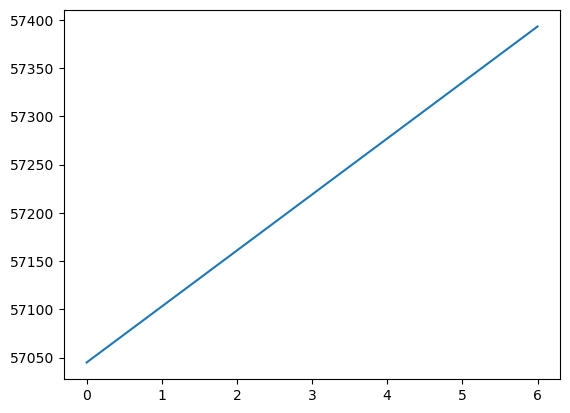

In [213]:
plt.plot(secs[2])

In [216]:
for i in range(4):
    x = range(7)
    y = secs[i] 
    slope, intercept, r_value, p_value, std_err = sp.stats.linregress(range(7), y)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    print(np.sum(np.square(residuals)))

1.4285714285693498
85.96428571424727
0.0
6726.535714285075


# B2

In [7]:
b2 = np.loadtxt('Daten_Frage_B2.txt', delimiter=',', skiprows=1)

In [17]:
print(np.mean(b2[:, 1]),
sp.stats.moment(b2[:, 1], [2, 3, 4]))

25.05571696645 [  9.11118776   4.63271028 250.85677937]


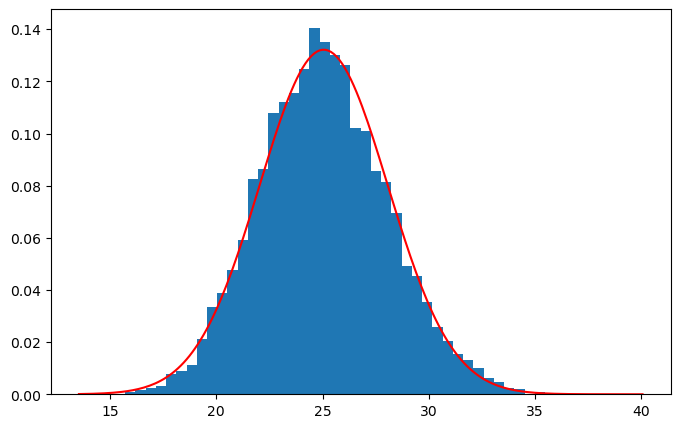

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(b2[:, 1], bins = 50, density=True)

mu, std = sp.stats.norm.fit(b2[:, 1])

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = sp.stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'r-',)

# C1

In [32]:
c1 = np.loadtxt('Daten_Frage_C1.txt', delimiter='	')

In [33]:
np.std(c1[:, 1])

np.float64(0.003321348866250454)

In [34]:
np.sqrt(np.var(c1[:, 1]) - 3e-6) * 1e-6

np.float64(2.833965118229788e-09)

In [37]:
spectrum = np.fft.fft(c1[:, 1])
f_sample = 10

In [38]:
c1

array([[ 0.00000000e+00, -1.73920288e-03],
       [ 1.00000000e-01, -2.06884554e-03],
       [ 2.00000000e-01, -1.55700664e-03],
       ...,
       [ 1.49800000e+02,  1.21390089e-03],
       [ 1.49900000e+02,  5.47246426e-03],
       [ 1.50000000e+02, -3.50516802e-03]], shape=(1501, 2))

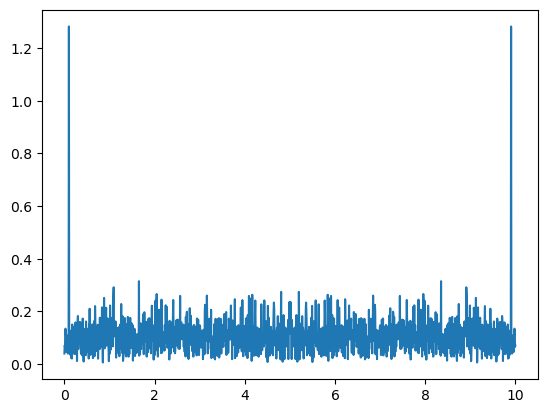

In [47]:
plt.plot(np.linspace(0, 10, spectrum.shape[0]), np.abs(spectrum))

In [42]:
np.argmax(np.abs(spectrum))

np.int64(15)

In [48]:
np.linspace(0, 10, spectrum.shape[0])[15]

np.float64(0.1)

In [50]:
averaged = np.array([np.mean(c1[k:k+30, 1]) for k in range(0, 1470)])

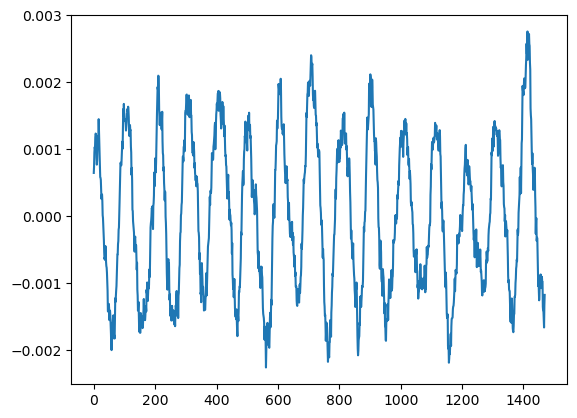

In [52]:
plt.plot(averaged)

In [57]:
np.std(averaged)

np.float64(0.0011309064828663748)

In [55]:
np.sqrt(np.var(averaged)) * 1e-6

np.float64(1.1309064828663748e-09)

# D1

In [59]:
1.3 ** 2 + 3 * 8.1 * 0.25 ** 3

2.0696875

In [226]:
np.sqrt(4 * 1.3 ** 2 * 0.4 ** 2 + 9 * 0.25 ** 6 * 0.64 ** 2 + 9 * 8.1 ** 2 * 0.25 ** 4 * 0.02 ** 2) 

np.float64(1.0408759006841306)

In [234]:
grad_f = np.array([2 * 1.3, 3 * 0.25 ** 3, 3 * 8.1 * 0.25 ** 2])

In [235]:
L = np.array([[0.4 ** 2, 0, 0], 
             [0, 0.64 ** 2, 0], 
             [0, 0, 0.02 ** 2]])

In [240]:
np.sqrt(grad_f.transpose() @ L @ grad_f)

np.float64(1.0408759006841306)

In [256]:
M = np.array([[0.4 ** 2, 0, 0], 
             [0, 0.64 ** 2, 0.67], 
             [0, 0.67, 0.02 ** 2]])

In [259]:
np.sqrt(grad_f.transpose() @ M @ grad_f) # error in the solution, they forgot to take the sqrt

np.float64(1.0857343712897738)

# D2

In [65]:
d2 = np.loadtxt('Daten_Frage_D2.txt', delimiter='	')

In [73]:
T = np.mean(d2[:, 1])

In [74]:
m = np.mean(d2[:, 2])

In [72]:
np.var(d2[:, 1])

np.float64(0.007230846480334927)

In [71]:
np.var(d2[:, 2])

np.float64(0.014727704505713372)

In [75]:
m * np.square(2 * np.pi / T)

np.float64(12.42342639322277)

In [354]:
grad_k = np.array([-8 * np.pi ** 2 * m / T ** 3, (2 * np.pi / T) ** 2])

In [355]:
Q = np.cov(d2[:, 1], d2[:, 2])

In [356]:
grad_k.transpose() @ Q @ grad_k # does not match solution (2.8)?

np.float64(2.6728332269544453)

In [357]:
Q

array([[0.00725495, 0.00540704],
       [0.00540704, 0.0147768 ]])

In [364]:
S = np.array([[0.0072, 0.005],
               [0.005, 0.015 ]])

In [365]:
grad_k.transpose() @ S @ grad_k

np.float64(2.907529691978461)

# 10

In [79]:
990 / (990 + 90)

0.9166666666666666

# G1

In [81]:
np.sqrt(0.3 * 0.7 ** 2 + 0.7 * 0.3 ** 2)

np.float64(0.45825756949558394)

# 19

In [83]:
import pandas as pd

In [84]:
df = pd.read_csv('coincidence_two_detectors.csv')

In [86]:
df.head()

,timestamp,top_counts,bottom_counts
0,0.0,7,10
1,0.5,11,11
2,1.0,5,5
3,1.5,8,10
4,2.0,10,5


In [87]:
top_val = np.array(df['top_counts'])

In [88]:
bot_val = np.array(df['bottom_counts'])

In [90]:
t = np.array(df['timestamp'])

In [91]:
top_thresh = np.mean(top_val) + 2 * np.std(top_val)

In [92]:
bot_thresh = np.mean(bot_val) + 2 * np.std(bot_val)

In [93]:
top_inc = top_val >= top_thresh
bot_inc = bot_val >= bot_thresh


In [96]:
print(t[top_inc])
print(t[bot_inc])

[ 12.   18.   28.5  35.5  51.   63.5  77.  101.5]
[ 12.5  20.   28.   51.5  66.   76.5  91.5 101.5]


# 20

## Aufgabe 1

In [98]:
df = pd.read_csv('photodetector_counts.csv')

In [99]:
df.head()

,timestamp,channel,counts_raw
0,0.0,1,43
1,0.0,2,48
2,0.0,3,45
3,0.0,4,60
4,0.0,5,57


In [101]:
t = np.array(df['timestamp'])
channel = np.array(df['channel'])
counts = np.array(df['counts_raw'])

In [106]:
t_100 = t[channel == 100]
counts_100 = counts[channel == 100]

In [107]:
np.mean(counts_100)

np.float64(28.592307692307692)

In [108]:
np.std(counts_100)

np.float64(5.479607164255136)

In [109]:
np.sqrt(np.mean(counts_100))

np.float64(5.347177544490896)

## Aufgabe 2

In [148]:
spectrum_channels = np.array([np.mean(counts[channel == k]) for k in range(1, 501)])

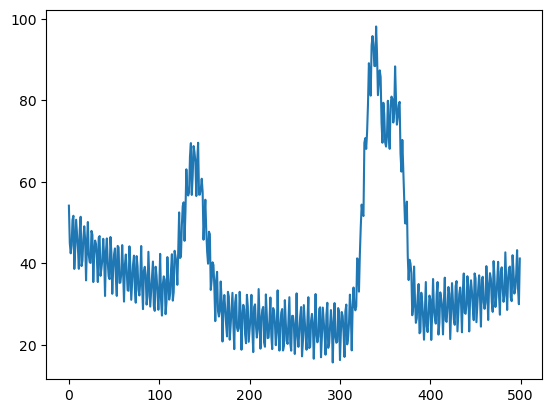

In [149]:
plt.plot(spectrum_channels)

## Aufgabe 3

In [151]:
mask = np.full(500, True)

In [159]:
mask[105:176] = False
mask[300:381] = False

In [160]:
channel

array([  1,   2,   3, ..., 498, 499, 500], shape=(130000,))

In [161]:
c = np.linspace(1, 500, 500)[mask]
B = spectrum_channels[mask]

In [164]:
B.shape

(348,)

In [167]:
np.polyfit(c, B, 2)

array([ 2.81566200e-04, -1.60222226e-01,  4.69460804e+01])

In [ ]:
a = np.linspace(1, 500, 500)
noise_fitted = 2.81566200e-4 * np.square(a)  -1.60222226e-01 * a + 4.69460804e+01

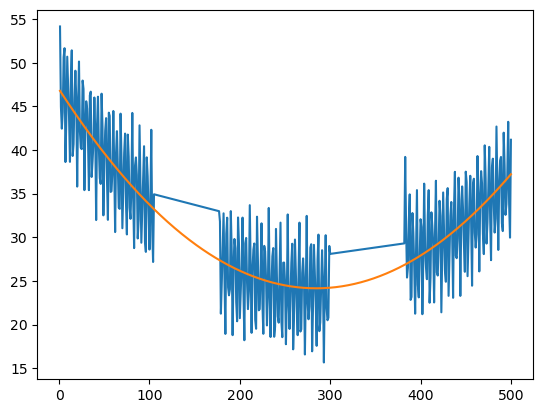

In [173]:
plt.plot(c, B, a, noise_fitted)

In [222]:
spectrum_channels[299]

np.float64(28.096153846153847)

In [224]:
spectrum_channels[381]

np.float64(29.3)

In [174]:
spectrum_filtered = spectrum_channels - noise_fitted

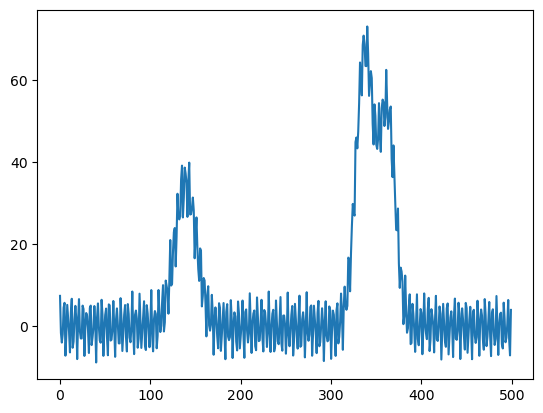

In [175]:
plt.plot(spectrum_filtered)

In [176]:
np.max(spectrum_filtered) # does not match the solution?

np.float64(73.11428397918462)

In [177]:
np.argmax(spectrum_filtered)

np.int64(340)

In [225]:
spectrum_channels[340] - 28.65

np.float64(69.51538461538462)